# Credit Applications EDA

Load both source tables, inspect their quality, and explore application behavior over time and by customer risk group.

## Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')

## Display raw data

In [2]:
# load both raw pandas DataFrames
data_dir = Path.cwd() / 'data'
if not (data_dir / 'credit_applications.csv').exists():
    data_dir = Path.cwd().parent / 'data'

credit_applications = pd.read_csv(data_dir / 'credit_applications.csv')
customers = pd.read_csv(data_dir / 'customers.csv')

In [3]:
print(f'credit_applications: {credit_applications.shape[0]} rows x {credit_applications.shape[1]} columns')
display(credit_applications)

credit_applications: 29996 rows x 5 columns


,Unnamed: 0,client_nr,yearmonth,credit_application,nr_credit_applications
0,1,1,201401,0,0
1,2,1,201402,0,0
2,3,1,201403,0,0
3,4,1,201404,0,0
4,5,1,201405,0,0
...,...,...,...,...,...
29991,29992,1000,201604,0,0
29992,29993,1000,201605,0,0
29993,29994,1000,201606,0,0
29994,29995,1000,201607,0,0


In [4]:
print(f'customers: {customers.shape[0]} rows x {customers.shape[1]} columns')
display(customers)

customers: 29996 rows x 11 columns


,Unnamed: 0,client_nr,yearmonth,total_nr_trx,nr_debit_trx,volume_debit_trx,nr_credit_trx,volume_credit_trx,min_balance,max_balance,CRG
0,1,1,201401,97,50,6527929,47,7454863,-7914288,25110651,1.00
1,2,1,201402,88,59,3475918,29,1895848,-8448513,25036651,1.00
2,3,1,201403,96,62,31316405,34,20083583,-10347650,18020151,1.00
3,4,1,201404,83,53,18669967,30,1091295,-15385039,13318200,1.00
4,5,1,201405,94,54,2893905,40,2034075,-15682170,2350000,1.00
...,...,...,...,...,...,...,...,...,...,...,...
29991,29992,1000,201604,2,1,605000,1,315800,131422,736422,NaN
29992,29993,1000,201605,5,3,607506,2,1210000,128916,735145,NaN
29993,29994,1000,201606,4,3,1211270,1,605000,127646,1338916,NaN
29994,29995,1000,201607,4,2,606253,2,920000,441393,1047646,NaN


## Data quality and structure

In [5]:
def quality_report(dataframe, name):
    """Display a concise data-quality report for a DataFrame.

    The report includes the DataFrame dimensions, column data types,
    missing-value counts and ratios, duplicate-row count, and summary
    statistics for numeric and categorical columns.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        DataFrame to profile.
    name : str
        Label displayed with the DataFrame dimensions.
    """
    print(f"{name}: {dataframe.shape[0]:,} rows x {dataframe.shape[1]} columns")

    print("\nColumn data types")
    display(dataframe.dtypes.rename("dtype").to_frame())

    print("\nMissing values")
    missing = dataframe.isna().sum().rename("missing_values").to_frame()
    missing["missing_ratio"] = missing["missing_values"].div(len(dataframe)).fillna(0)
    display(missing[missing["missing_values"] > 0].sort_values("missing_ratio", ascending=False))

    print(f"\nDuplicate rows: {dataframe.duplicated().sum():,}")

    print("\nSummary statistics")
    display(dataframe.describe(include="all").T)


### Quality report Credit applications table

In [6]:
quality_report(credit_applications, "Credit applications")

Credit applications: 29,996 rows x 5 columns

Column data types


,dtype
Unnamed: 0,int64
client_nr,int64
yearmonth,int64
credit_application,int64
nr_credit_applications,int64



Missing values


,missing_values,missing_ratio



Duplicate rows: 0

Summary statistics


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"29,996.00","14,998.50","8,659.24",1.00,"7,499.75","14,998.50","22,497.25","29,996.00"
client_nr,"29,996.00",481.56,281.32,1.00,237.00,479.00,721.00,"1,000.00"
yearmonth,"29,996.00","201,493.68",77.36,"201,401.00","201,409.00","201,505.00","201,601.00","201,608.00"
credit_application,"29,996.00",0.07,0.25,0.00,0.00,0.00,0.00,1.00
nr_credit_applications,"29,996.00",0.09,0.36,0.00,0.00,0.00,0.00,7.00


### Quality report Customers table

In [7]:
quality_report(customers, "Customers")

Customers: 29,996 rows x 11 columns

Column data types


,dtype
Unnamed: 0,int64
client_nr,int64
yearmonth,int64
total_nr_trx,int64
nr_debit_trx,int64
volume_debit_trx,int64
nr_credit_trx,int64
volume_credit_trx,int64
min_balance,int64
max_balance,int64



Missing values


,missing_values,missing_ratio
CRG,5537,0.18



Duplicate rows: 0

Summary statistics


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"29,996.00","14,998.50","8,659.24",1.00,"7,499.75","14,998.50","22,497.25","29,996.00"
client_nr,"29,996.00",481.56,281.32,1.00,237.00,479.00,721.00,"1,000.00"
yearmonth,"29,996.00","201,493.68",77.36,"201,401.00","201,409.00","201,505.00","201,601.00","201,608.00"
total_nr_trx,"29,996.00",166.43,220.95,1.00,76.00,129.00,205.00,"6,341.00"
nr_debit_trx,"29,996.00",75.79,60.06,0.00,38.00,66.00,101.00,"1,590.00"
volume_debit_trx,"29,996.00","11,212,898.00","16,175,957.73",0.00,"3,072,750.25","6,822,769.00","13,866,561.25","798,047,977.00"
nr_credit_trx,"29,996.00",90.64,192.24,0.00,33.00,56.00,102.00,"6,325.00"
volume_credit_trx,"29,996.00","11,269,063.11","16,249,981.84",0.00,"3,148,067.50","6,934,694.00","13,942,573.00","877,532,140.00"
min_balance,"29,996.00","-5,523,773.38","13,575,174.77","-346,712,718.00","-7,895,863.50","-2,957,198.00","16,902.75","210,978,316.00"
max_balance,"29,996.00","3,752,692.59","16,169,373.88","-248,520,614.00","-1,868,001.50","1,040,997.50","5,806,224.00","372,231,851.00"


## Validate documented column logic

Before combining the tables, validate the relationships described in the source documentation. First, check that the application flag and application count agree. Then, check that the customer transaction and balance fields are internally consistent.

The `credit_application` field should be `1` whenever `nr_credit_applications` is greater than `0`, and otherwise `0`. The first check below tests both directions of this relationship.

In [15]:
# Check whether the application flag agrees with the application count.
credit_applications_issue1 = credit_applications[
    (credit_applications["nr_credit_applications"] == 0)
    & (credit_applications["credit_application"] > 0)
]
num_rows_issue1 = credit_applications_issue1.shape[0]

credit_applications_issue2 = credit_applications[
    (credit_applications["nr_credit_applications"] > 0)
    & (credit_applications["credit_application"] == 0)
]
num_rows_issue2 = credit_applications_issue2.shape[0]

print(f"Issue 1 - application flag is 1, but application count is 0: {num_rows_issue1} rows")
print(f"Issue 2 - application count is positive, but application flag is 0: {num_rows_issue2} rows")

if num_rows_issue1 > 0 or num_rows_issue2 > 0:
    print("Issues found in the application flag and count relationship.")
else:
    print("No issues found in the application flag and count relationship.")

Issue 1 - application flag is 1, but application count is 0: 0 rows
Issue 2 - application count is positive, but application flag is 0: 0 rows
No issues found in the application flag and count relationship.


In [16]:
# Check whether debit transaction counts and volumes are logically consistent.
debit_transactions_issue = customers[
    ((customers["nr_debit_trx"] > 0) & (customers["volume_debit_trx"] == 0))
    | ((customers["volume_debit_trx"] > 0) & (customers["nr_debit_trx"] == 0))
]
num_rows_debit_issue = debit_transactions_issue.shape[0]

# Check whether credit transaction counts and volumes are logically consistent.
credit_transactions_issue = customers[
    ((customers["nr_credit_trx"] > 0) & (customers["volume_credit_trx"] == 0))
    | ((customers["volume_credit_trx"] > 0) & (customers["nr_credit_trx"] == 0))
]
num_rows_credit_issue = credit_transactions_issue.shape[0]

# Check that minimum balances do not exceed maximum balances.
balance_issue = customers[customers["min_balance"] > customers["max_balance"]]
num_rows_balance_issue = balance_issue.shape[0]

# Check that total transactions equal debit transactions plus credit transactions.
total_transactions_issue = customers[
    customers["total_nr_trx"] != customers["nr_debit_trx"] + customers["nr_credit_trx"]
]
num_rows_total_transactions_issue = total_transactions_issue.shape[0]

print(f"Debit transaction count/volume issue: {num_rows_debit_issue} rows")
print(f"Credit transaction count/volume issue: {num_rows_credit_issue} rows")
print(f"Minimum/maximum balance issue: {num_rows_balance_issue} rows")
print(f"Total transaction count issue: {num_rows_total_transactions_issue} rows")

if any(
    (
        num_rows_debit_issue,
        num_rows_credit_issue,
        num_rows_balance_issue,
        num_rows_total_transactions_issue,
    )
):
    print("Issues found in customer transaction and balance data.")
else:
    print("No issues found in customer transaction and balance data.")

Debit transaction count/volume issue: 0 rows
Credit transaction count/volume issue: 0 rows
Minimum/maximum balance issue: 0 rows
Total transaction count issue: 0 rows
No issues found in customer transaction and balance data.


### Key validation and table merge

The two tables are joined by `client_nr` and `yearmonth`. Before merging, verify that this combination identifies at most one row in each table. A one-to-one merge then combines the application outcome with the corresponding customer information.

In [13]:
key_columns = ['client_nr', 'yearmonth']

# Check that client_nr + yearmonth identifies at most one row in each table.
credit_application_duplicate_keys = credit_applications.duplicated(key_columns).sum()
customer_duplicate_keys = customers.duplicated(key_columns).sum()
print(f'Credit application duplicate keys: {credit_application_duplicate_keys:,}')
print(f'Customer duplicate keys: {customer_duplicate_keys:,}')

# Merge the validated tables and require a one-to-one relationship.
eda = credit_applications.merge(
    customers,
    on=key_columns,
    how='inner',
    validate='one_to_one',
    suffixes=('_application', '_customer'),
)
print(f'Merged rows: {len(eda)}')
display(eda.head())

Credit application duplicate keys: 0
Customer duplicate keys: 0
Merged rows: 29996


,Unnamed: 0_application,client_nr,yearmonth,credit_application,nr_credit_applications,Unnamed: 0_customer,total_nr_trx,nr_debit_trx,volume_debit_trx,nr_credit_trx,volume_credit_trx,min_balance,max_balance,CRG
0,1,1,201401,0,0,1,97,50,6527929,47,7454863,-7914288,25110651,1.00
1,2,1,201402,0,0,2,88,59,3475918,29,1895848,-8448513,25036651,1.00
2,3,1,201403,0,0,3,96,62,31316405,34,20083583,-10347650,18020151,1.00
3,4,1,201404,0,0,4,83,53,18669967,30,1091295,-15385039,13318200,1.00
4,5,1,201405,0,0,5,94,54,2893905,40,2034075,-15682170,2350000,1.00


## Distributions, application rates, and time trends

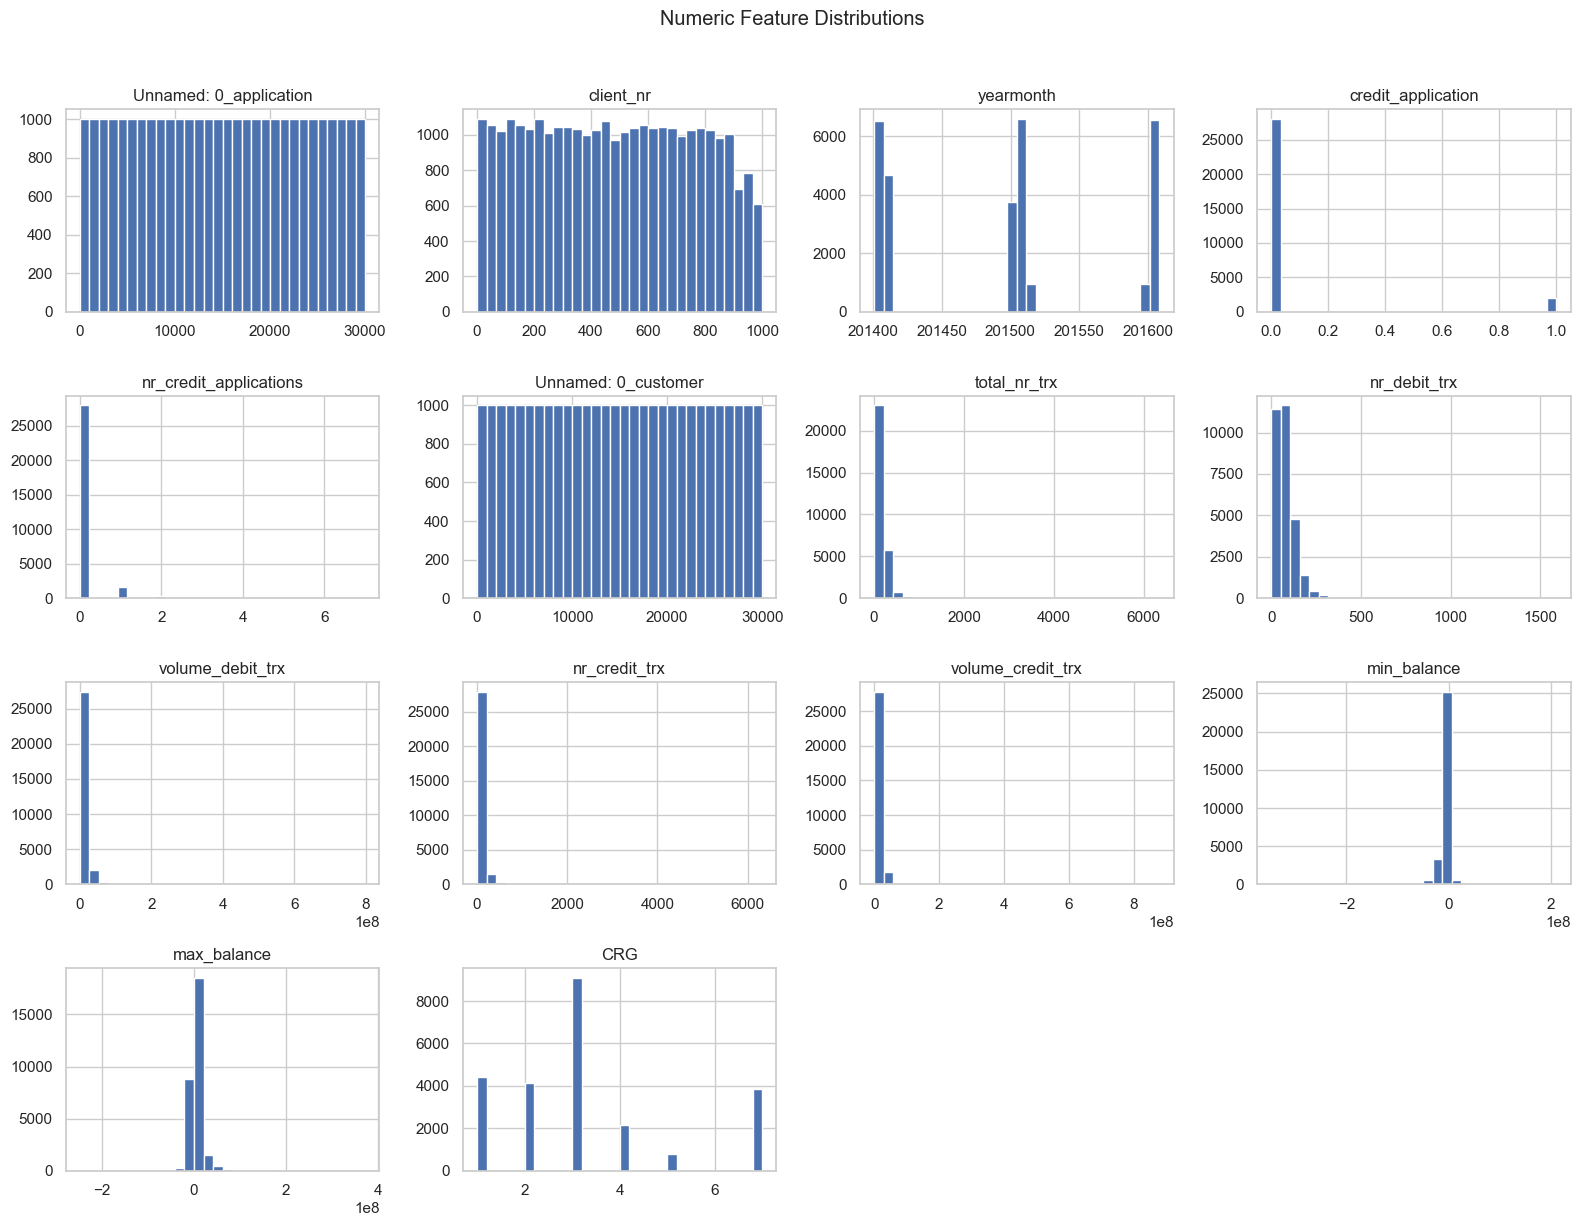

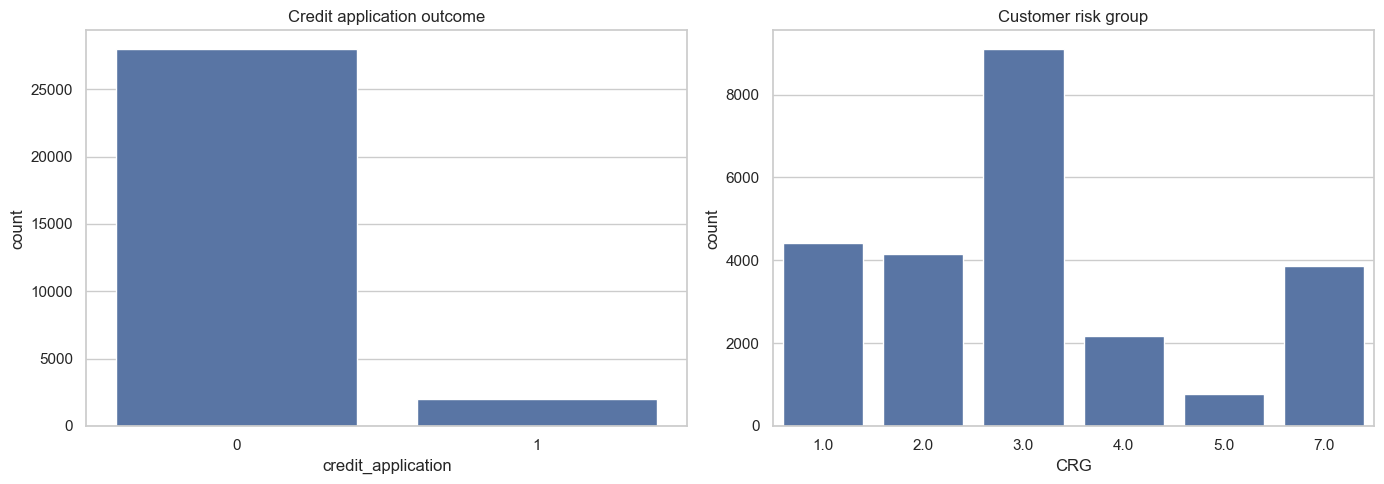

,application_rate,observations,applications
CRG,,,
5.00,14.27,778,111
7.00,12.42,3858,479
4.00,10.74,2161,232
2.00,7.37,4141,305
3.00,6.67,9097,607
1.00,3.37,4424,149
NaN,2.56,5537,142


In [10]:
numeric_columns = eda.select_dtypes(include=np.number).columns.tolist()
eda[numeric_columns].hist(figsize=(16, 12), bins=30, edgecolor='white')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=eda, x='credit_application', ax=axes[0])
axes[0].set_title('Credit application outcome')
sns.countplot(data=eda, x='CRG', order=sorted(eda['CRG'].dropna().unique()), ax=axes[1])
axes[1].set_title('Customer risk group')
plt.tight_layout()
plt.show()

application_rate_by_crg = eda.groupby('CRG', dropna=False)['credit_application'].agg(application_rate='mean', observations='size', applications='sum').sort_values('application_rate', ascending=False)
application_rate_by_crg['application_rate'] *= 100
display(application_rate_by_crg)

,application_rate,applications,customers
yearmonth,,,
201401,6.13,57,930
201402,6.02,56,931
201403,5.91,55,931
201404,5.69,53,932
201405,7.51,70,932
201406,6.97,65,932
201407,7.48,70,936
201408,5.88,55,935
201409,8.45,79,935


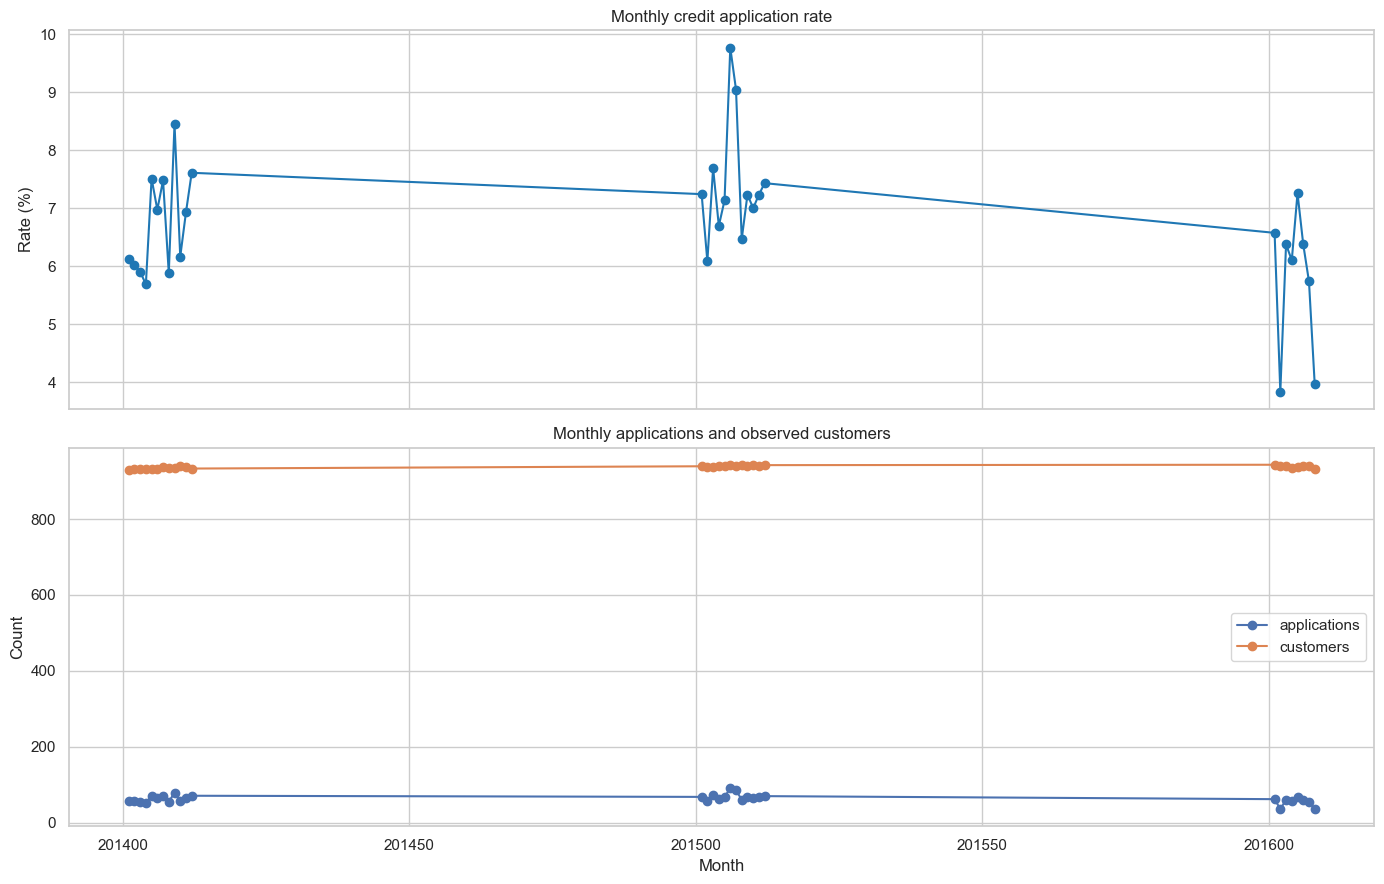

In [11]:
monthly = eda.groupby('yearmonth').agg(application_rate=('credit_application', 'mean'), applications=('credit_application', 'sum'), customers=('client_nr', 'nunique'))
monthly['application_rate'] *= 100
display(monthly)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
monthly['application_rate'].plot(ax=axes[0], marker='o', color='#1f77b4')
axes[0].set(title='Monthly credit application rate', ylabel='Rate (%)')
monthly[['applications', 'customers']].plot(ax=axes[1], marker='o')
axes[1].set(title='Monthly applications and observed customers', ylabel='Count', xlabel='Month')
plt.tight_layout()
plt.show()

## Relationships and correlations

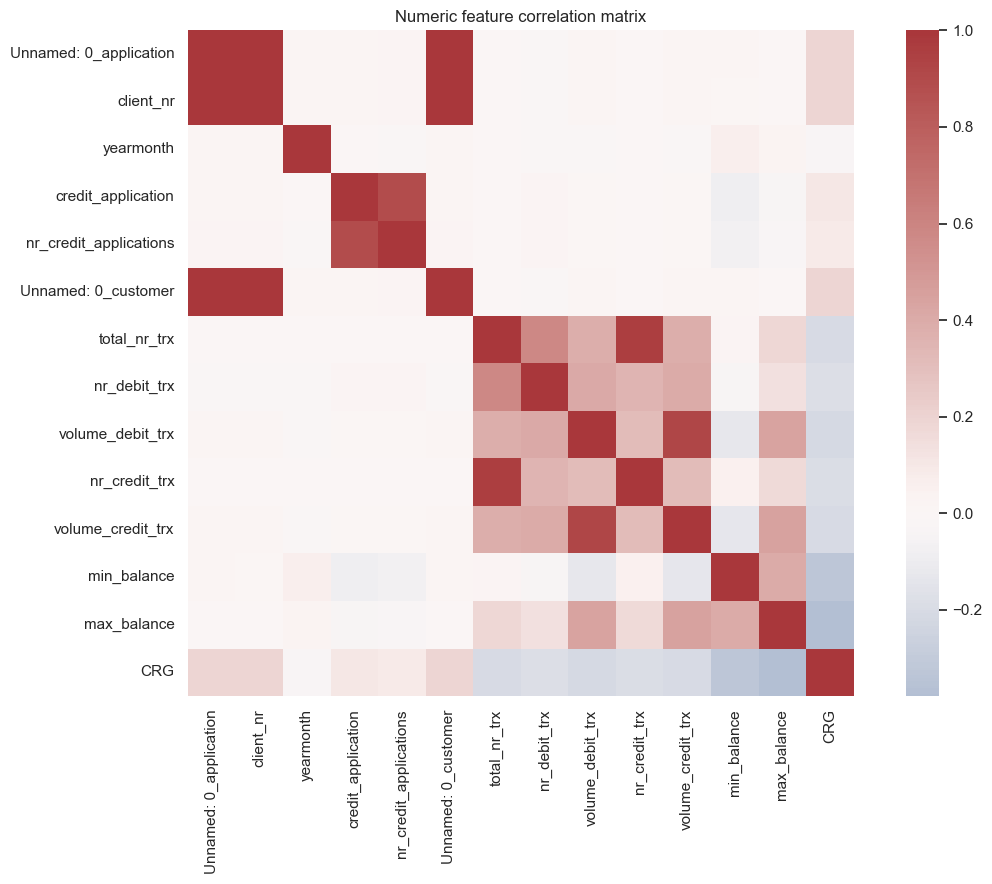

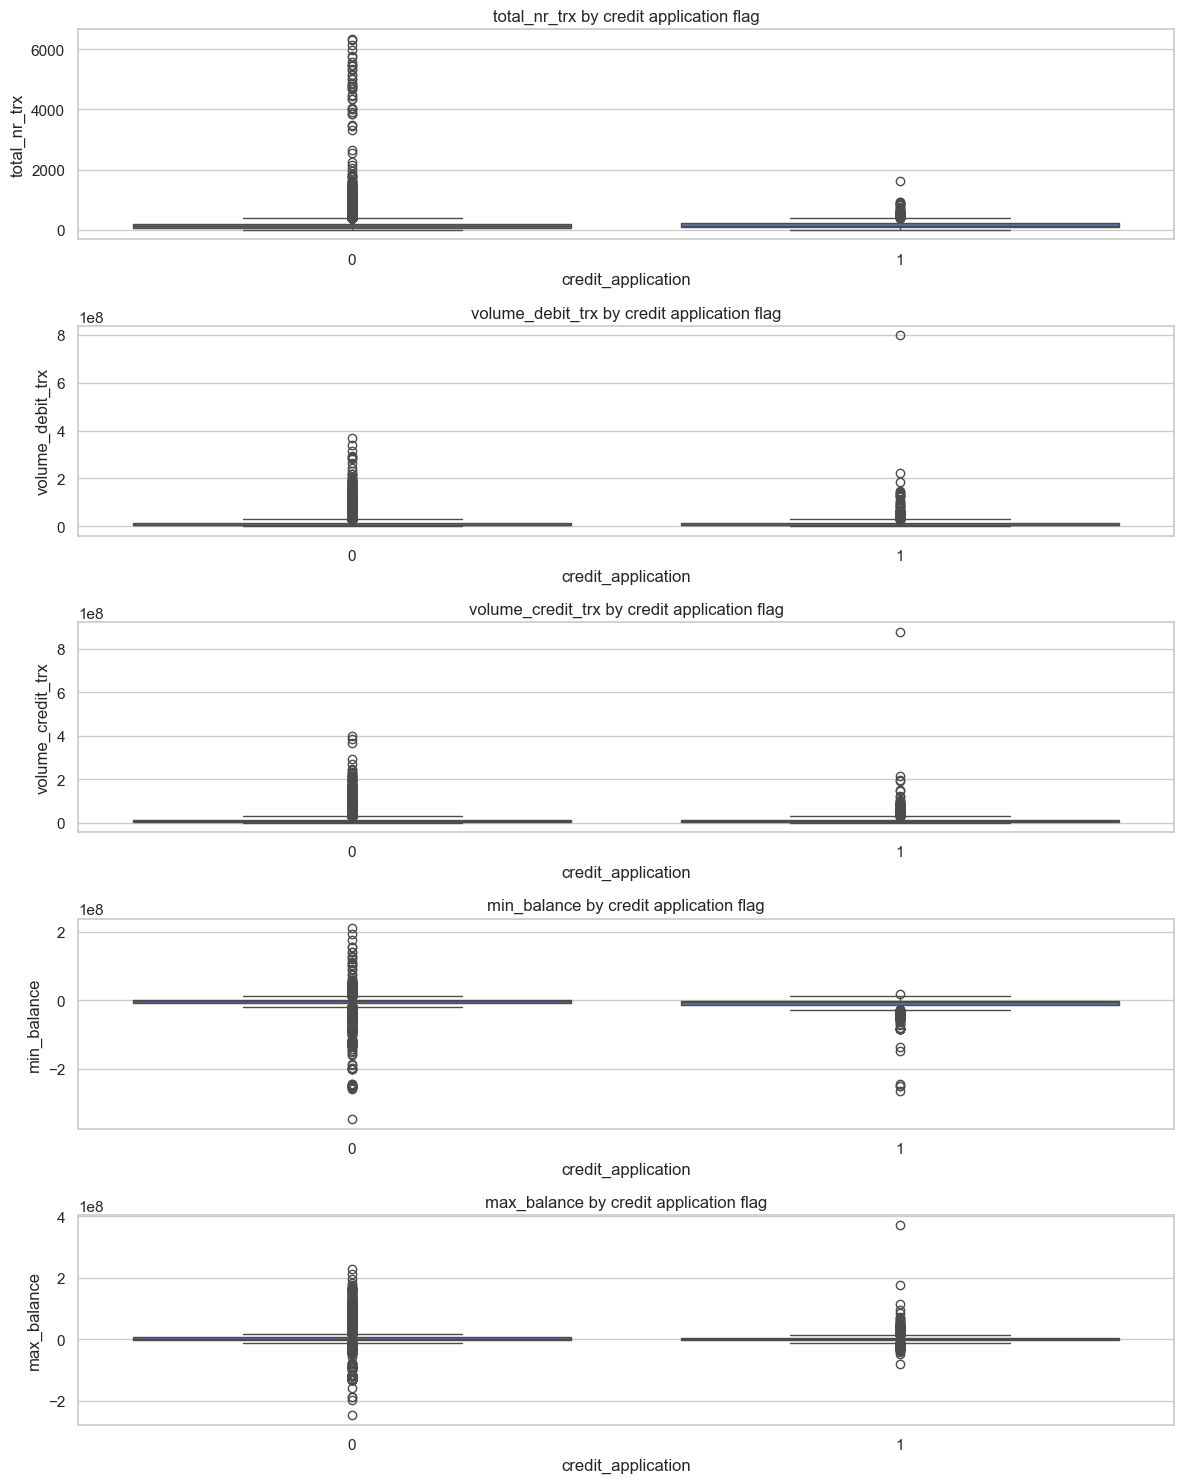

In [12]:
correlation = eda.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 9))
sns.heatmap(correlation, cmap='vlag', center=0, square=True)
plt.title('Numeric feature correlation matrix')
plt.tight_layout()
plt.show()

plot_columns = ['total_nr_trx', 'volume_debit_trx', 'volume_credit_trx', 'min_balance', 'max_balance']
available_plot_columns = [column for column in plot_columns if column in eda.columns]
fig, axes = plt.subplots(len(available_plot_columns), 1, figsize=(12, 3 * len(available_plot_columns)), squeeze=False)
for axis, column in zip(axes.flat, available_plot_columns):
    sns.boxplot(data=eda, x='credit_application', y=column, ax=axis)
    axis.set_title(f'{column} by credit application flag')
plt.tight_layout()
plt.show()